[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aubreycoffey/single-cell-analysis-pipeline/blob/main/notebooks/05_tcr_integration.ipynb)

# Notebook 5: TCR Integration with Scirpy

This notebook integrates T-cell receptor (TCR) sequence data with the scRNA-seq data using Scirpy. We perform:
- Loading and QC of TCR data
- Clonotype assignment
- Clonal expansion analysis
- Overlaying TCR features onto the UMAP embedding

## Google Drive setup

Mount Drive to persist data between notebook sessions. All `.h5ad` files will be saved to `MyDrive/scrna-pbmc-pipeline-data/`.

In [17]:
from google.colab import drive
drive.mount('/content/drive')
import os
DATA_DIR = '/content/drive/MyDrive/scrnaseq-pbmc-pipeline-data'
os.makedirs(DATA_DIR, exist_ok=True)
print(f'Data directory: {DATA_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/scrnaseq-pbmc-pipeline-data


In [18]:
import sys
!{sys.executable} -m pip install -q scanpy scirpy leidenalg python-igraph

In [19]:
import scanpy as sc
import scirpy as ir
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')
print(f'Scirpy version: {ir.__version__}')

Scirpy version: 0.24.0


/tmp/ipykernel_27375/684481783.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white')


In [20]:
adata = sc.read_h5ad(f'{DATA_DIR}/pbmc_trajectory.h5ad')
print(adata)

AnnData object with n_obs × n_vars = 2638 × 1830
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type', 'dpt_pseudotime'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'cell_type_colors', 'cell_type_sizes', 'dendrogram_cell_type', 'diffmap_evals', 'draw_graph', 'hvg', 'iroot', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'paga', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_diffmap', 'X_draw_graph_fr', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'


## 1. Load TCR data

We use the paired TCR dataset from Wu et al. 2020 (available via Scirpy).


In [21]:
adata_tcr = ir.datasets.wu2020_3k()
print(adata_tcr)
print('\nTCR obs columns:', list(adata_tcr.obs.columns[:10]))

MuData object with n_obs × n_vars = 3000 × 30727
  2 modalities
    gex:	3000 × 30727
      obs:	'cluster_orig', 'patient', 'sample', 'source'
      uns:	'cluster_orig_colors'
      obsm:	'X_umap_orig'
    airr:	3000 × 0
      obs:	'high_confidence', 'is_cell', 'clonotype_orig'
      obsm:	'airr'

TCR obs columns: ['gex:cluster_orig', 'gex:patient', 'gex:sample', 'gex:source', 'airr:high_confidence', 'airr:is_cell', 'airr:clonotype_orig']


/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## 2. TCR quality control

Scirpy provides standard QC metrics for TCR data — checking for cells with dual alpha/beta chains, orphan chains, and multichain cells.

<Axes: title={'center': 'Number of cells in chain_pairing by gex:source'}, xlabel='chain_pairing', ylabel='Number of cells'>

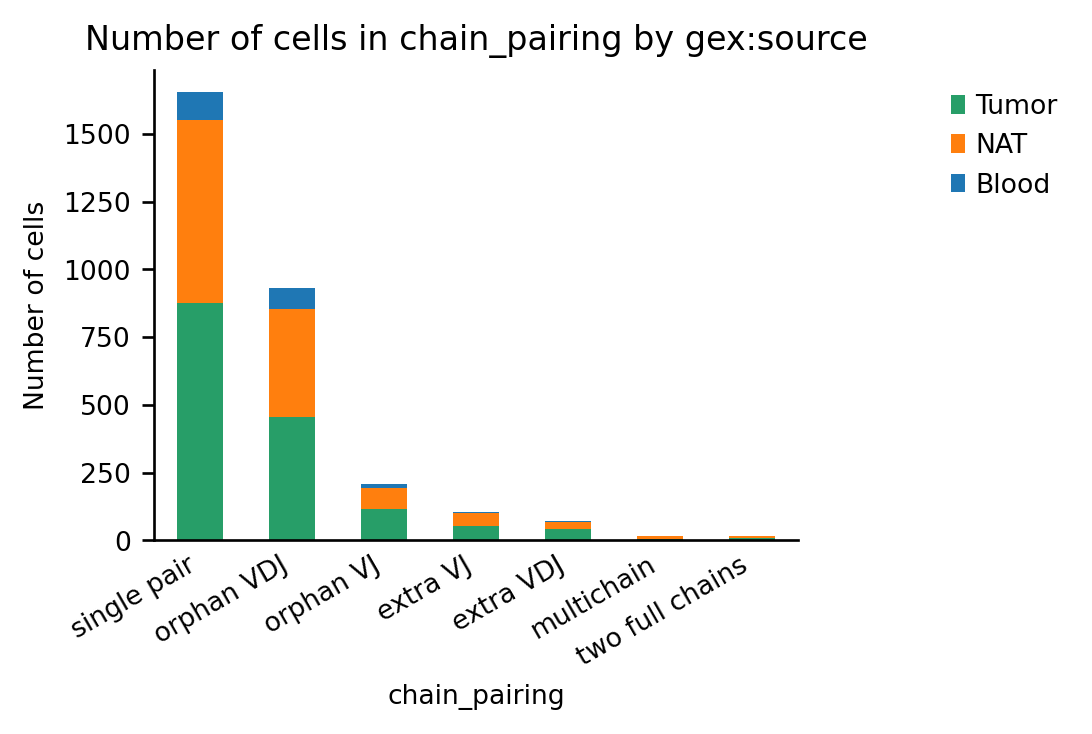

In [24]:
ir.tl.chain_qc(adata_tcr)


ir.pl.group_abundance(adata_tcr, groupby='chain_pairing', target_col='gex:source')

## 3. Clonotype definition

Clonotypes are defined by identical CDR3 amino acid sequences on both the alpha and beta chains. Cells sharing a clonotype are clonally related (descended from the same T cell).

In [28]:
ir.pp.ir_dist(adata_tcr)
ir.tl.define_clonotypes(adata_tcr, receptor_arms='all', dual_ir='primary_only')
print(f'Unique clonotypes: {adata_tcr.obs["airr:clone_id"].nunique()}')

Unique clonotypes: 2532


## 4. Clonal expansion

Expanded clonotypes (clones with many cells) suggest antigen-driven proliferation. We categorize cells by clonal expansion size.

/usr/local/lib/python3.12/dist-packages/scirpy/tl/_clonal_expansion.py:111: FutureWarning: The argument `clip_at` is deprecated. Please use `brekpoints` instead.
  warnings.warn("The argument `clip_at` is deprecated. Please use `brekpoints` instead.", category=FutureWarning)


<Axes: >

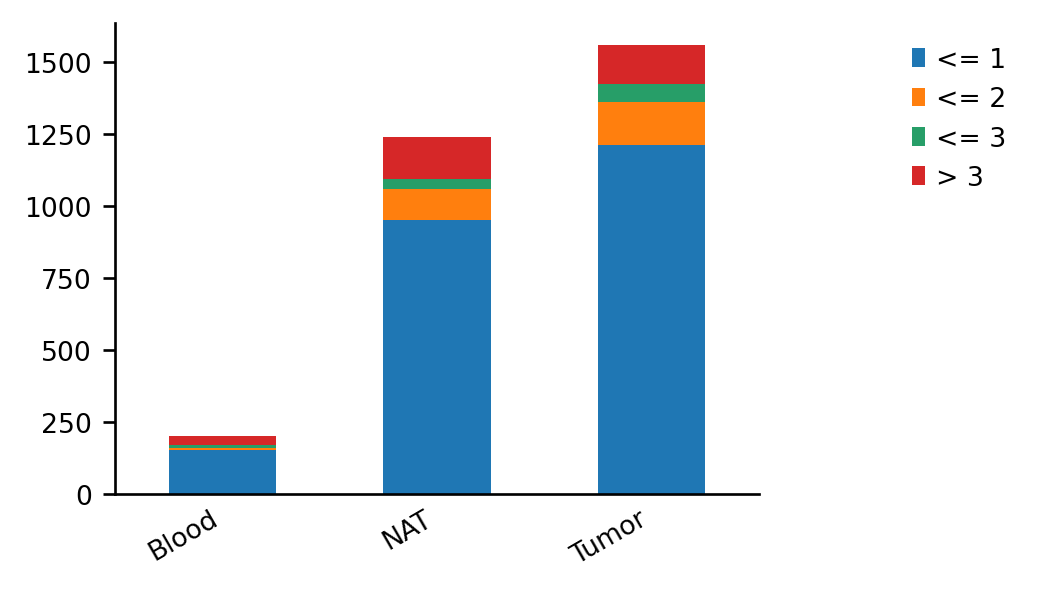

In [30]:
ir.tl.clonal_expansion(adata_tcr)
ir.pl.clonal_expansion(adata_tcr, groupby='gex:source', clip_at=4, normalize=False)

## 5. Merge TCR data into scRNA-seq AnnData

We merge the TCR metadata into the main `adata` object by matching cell barcodes. Cells without a TCR (non-T cells) will have NaN values.

In [32]:
# Note: Wu et al. TCR data and PBMC 3k have different barcodes
# (they are different studies). In a real project, both modalities
# come from the same 10x run and barcodes match automatically.
# Here we demonstrate the merge by transferring TCR data from the
# TCR object directly, using its own cell annotations.

tcr_cols = ['airr:chain_pairing', 'airr:clone_id', 'airr:clonal_expansion']

# Rename for cleaner obs columns in adata_tcr
adata_tcr.obs['chain_pairing'] = adata_tcr.obs['airr:chain_pairing']
adata_tcr.obs['clone_id'] = adata_tcr.obs['airr:clone_id']
adata_tcr.obs['clonal_expansion'] = adata_tcr.obs['airr:clonal_expansion']

# For visualization, work directly with adata_tcr
print(f"TCR cells available for downstream analysis: {adata_tcr.n_obs}")
print('TCR columns ready.')

TCR cells available for downstream analysis: 3000
TCR columns ready.


## 6. Visualize on UMAP

In [38]:
import numpy as np

# Copy the existing UMAP from the gex modality into the top-level obsm
adata_tcr.obsm['X_umap'] = adata_tcr['gex'].obsm['X_umap_orig']

print('UMAP ready.')

UMAP ready.


/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  else adata.obs_vector(k, layer=layer)
/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future.
  else adata.obs_vector(k, layer=layer)


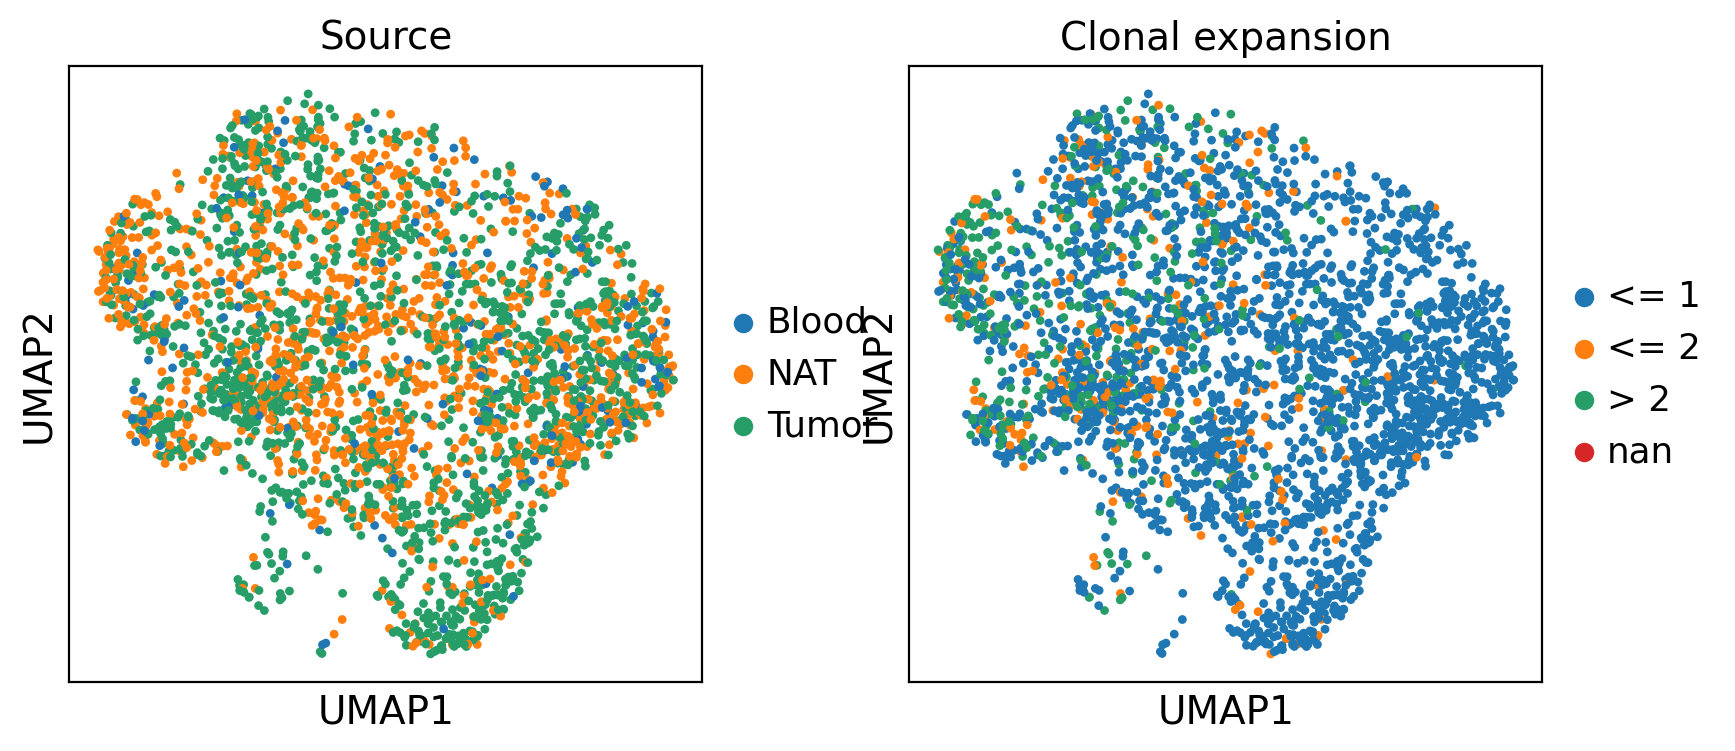

In [39]:
sc.pl.umap(adata_tcr, color=['gex:source', 'clonal_expansion'], ncols=2,
           title=['Source', 'Clonal expansion'])

/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/usr/local/lib/python3.12/dist-packages/scanpy/plotting/_utils.py:1183: FutureWarning: The method obs_vector is deprecated and will be removed in the future

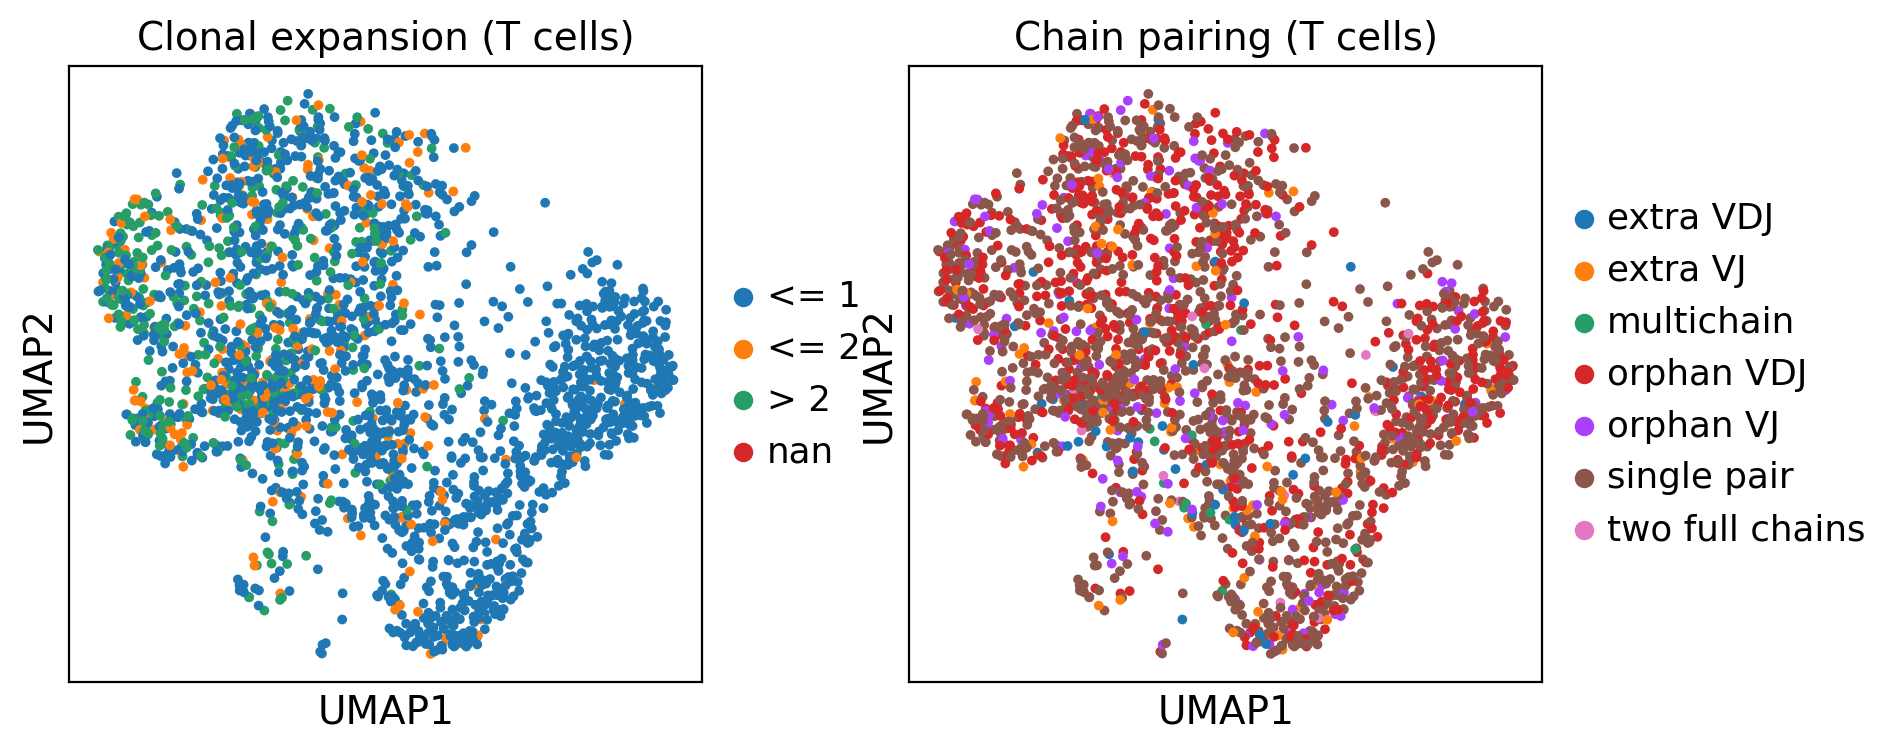

In [41]:
# Only T cells — show expansion
t_cell_mask = adata_tcr['gex'].obs['cluster_orig'].str.contains('T', case=False, na=False)
t_cells_tcr = adata_tcr[t_cell_mask].copy()

sc.pl.umap(t_cells_tcr, color=['clonal_expansion', 'chain_pairing'], ncols=2,
           title=['Clonal expansion (T cells)', 'Chain pairing (T cells)'])

## 7. Clonotype abundance by cell type

In [43]:
import pandas as pd

tcr_df = adata_tcr.obs[['gex:cluster_orig', 'clone_id', 'clonal_expansion']].dropna()
expansion_summary = (
    tcr_df.groupby(['gex:cluster_orig', 'clonal_expansion'])
    .size()
    .reset_index(name='n_cells')
)
print(expansion_summary.to_string())

   gex:cluster_orig clonal_expansion  n_cells
0            3.1-MT             <= 1       93
1            3.1-MT             <= 2       14
2            3.1-MT              > 2       31
3            3.1-MT              nan        0
4           4.1-Trm             <= 1      221
5           4.1-Trm             <= 2       24
6           4.1-Trm              > 2       17
7           4.1-Trm              nan        0
8         4.2-RPL32             <= 1      129
9         4.2-RPL32             <= 2        5
10        4.2-RPL32              > 2        7
11        4.2-RPL32              nan        0
12         4.3-TCF7             <= 1      359
13         4.3-TCF7             <= 2        3
14         4.3-TCF7              > 2        2
15         4.3-TCF7              nan        0
16          4.4-FOS             <= 1      313
17          4.4-FOS             <= 2       12
18          4.4-FOS              > 2        8
19          4.4-FOS              nan        0
20        4.5-IL6ST             <=

/tmp/ipykernel_27375/3754553166.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tcr_df.groupby(['gex:cluster_orig', 'clonal_expansion'])


### Interpretation

Expanded clonotypes concentrated in CD8+ T cells indicate antigen-experienced, clonally expanded cytotoxic T cells — a hallmark of adaptive immune responses. Naive CD4+ T cells are expected to show mostly non-expanded (singleton) clonotypes.

This multimodal view — combining transcriptomic state (clustering) with receptor identity (clonotype) — demonstrates the core principle behind joint TCR + gene expression analysis. In a real project where both modalities come from the same 10x run, this approach extends naturally to pseudotime and trajectory analysis, as in the mvTCR / joint embedding framework used in the TUM single-cell biology project.

In [44]:
adata.write(f'{DATA_DIR}/pbmc_final.h5ad')
print('Final AnnData saved to ../data/pbmc_final.h5ad')
print('\nPipeline complete!')

Final AnnData saved to ../data/pbmc_final.h5ad

Pipeline complete!
